# 06 · Conformal Prediction: Membuat Interval Tetap Jujur

Notebook 05 menunjukkan bahwa saat **shock**, coverage interval 80% semua model anjlok ke ~40%.
Model menjadi *terlalu percaya diri* tepat ketika ketidakpastian paling penting.

**Conformal prediction** memperbaiki interval *setelah* model dilatih, hanya dengan melihat seberapa
sering interval meleset:

| Metode | Cara kerja | Kalibrasi pada |
|---|---|---|
| **CQR** (Romano dkk., 2019) | lebarkan/sempitkan interval sebesar kuantil skor meleset | data validasi (statik) |
| **ACI** (Gibbs & Candès, 2021) | setiap forecast yang terbukti meleset → interval berikutnya melebar | jendela 30 forecast terbaru (online) |

Skor kesesuaian untuk interval (lo, hi): $s = \max(lo - y,\; y - hi)$. Nilai positif berarti meleset.

**Privasi:** kalibrasi dilakukan **lokal di tiap bank**, sehingga skor tidak pernah dikirim ke server.
Conformal bisa langsung dipasang di atas model federated mana pun.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.conformal import aci, cqr, online_bias_shift
from fedprob.experiment import run_experiment_cached, method_label
from fedprob.metrics import evaluate
from fedprob.plots import plot_fan

SC = ["normal", "data_langka", "shock"]
results = {s: run_experiment_cached(s, cache_dir="../results", verbose=False) for s in SC}
M = ["fedavg", "fedavg+cqr", "fedavg+aci", "oracle"]
tab = pd.concat({s: r.summary().loc[M, ["CRPS", "Coverage80", "Coverage90", "Lebar80"]] for s, r in results.items()}, axis=1)
tab.rename(index=method_label)

normal                                \
                                   CRPS Coverage80 Coverage90 Lebar80   
method                                                                  
Federated (FedAvg)                0.203      0.681      0.809   0.908   
Federated (FedAvg) + CQR          0.201      0.683      0.820   0.916   
Federated (FedAvg) + ACI adaptif  0.205      0.811      0.909   1.228   
Oracle (distribusi sebenarnya)    0.162      0.724      0.844   0.778   

                                 data_langka                                \
                                        CRPS Coverage80 Coverage90 Lebar80   
method                                                                       
Federated (FedAvg)                     0.194      0.727      0.855   0.964   
Federated (FedAvg) + CQR               0.195      0.687      0.834   0.893   
Federated (FedAvg) + ACI adaptif       0.197      0.812      0.918   1.181   
Oracle (distribusi sebenarnya)         0.157      0.724      0.844   0.754   

                                  shock                                
                                   CRPS Coverage80 Coverage90 Lebar80  
method                                                                 
Federated (FedAvg)                0.504      0.403      0.484   0.701  
Federated (FedAvg) + CQR          0.502      0.398      0.488   0.707  
Federated (FedAvg) + ACI adaptif  0.528      0.809      0.872   2.797  
Oracle (distribusi sebenarnya)    0.185      0.742      0.856   0.921

**Cara membaca:**
- **ACI** membawa coverage 80% ke ~81% di **semua** skenario. CRPS hanya sedikit berubah pada kondisi normal.
- Pada `shock`, **ACI memulihkan coverage 80% dari ~40% ke ~81%**. Interval menjadi jauh lebih lebar, dan
  itulah sikap yang *jujur*: model mengakui bahwa ia sedang tidak yakin. CRPS sedikit memburuk karena pusat
  prediksinya tetap salah.
- **CQR statik hampir tidak membantu**, bahkan menurunkan coverage pada `data_langka` (73% → 69%). Kalibrasinya
  memakai periode validasi, yang perilakunya berbeda dari periode uji: perubahan periode inilah yang tidak bisa
  ditangani metode statik.

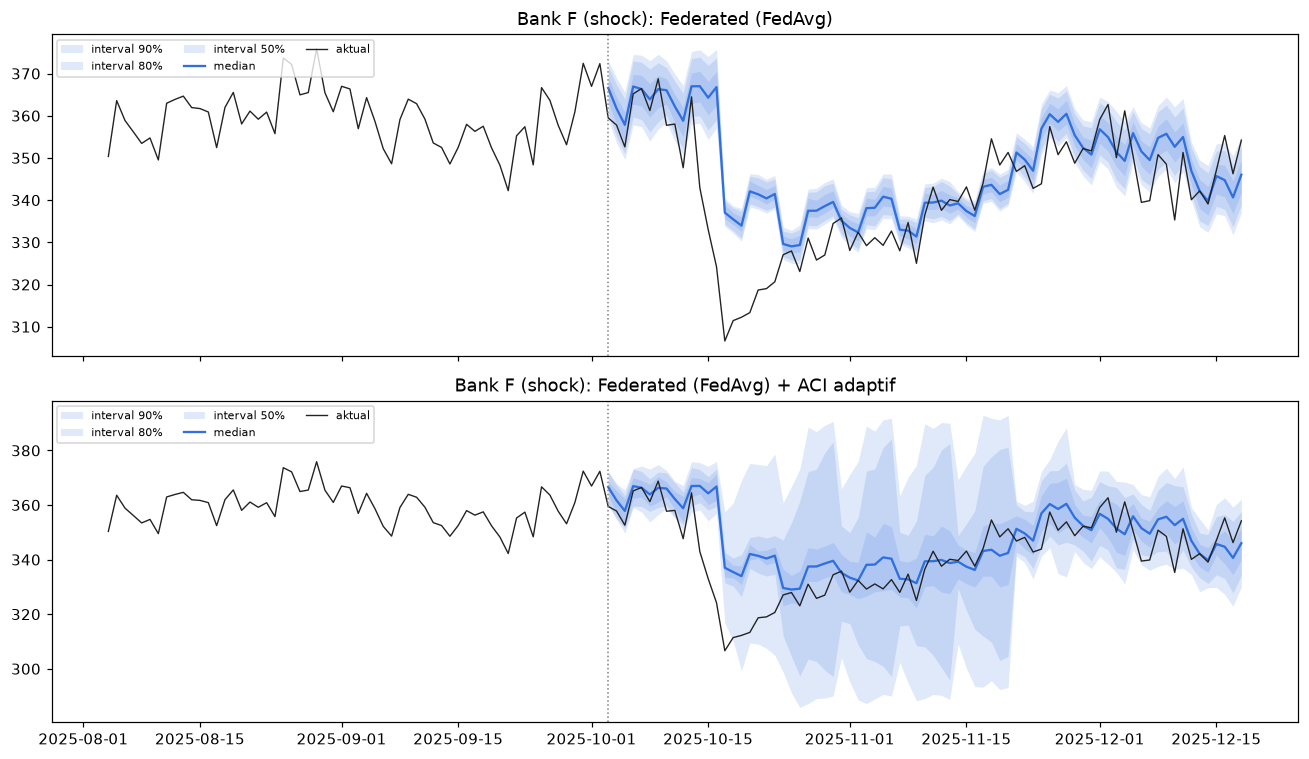

In [3]:
r = results["shock"]; k = 5; c = r.clients[k]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, m in zip(axes, ["fedavg", "fedavg+aci"]):
    plot_fan(r.sim, k, r.pred_original_scale(m, k), c.test.origins, ax=ax, title=f"{c.name} (shock): {method_label(m)}")
plt.tight_layout()

## Coverage dari waktu ke waktu
Coverage bergulir (rata-rata 7 origin) untuk interval 80%, semua bank. Garis putus-putus = target 80%.

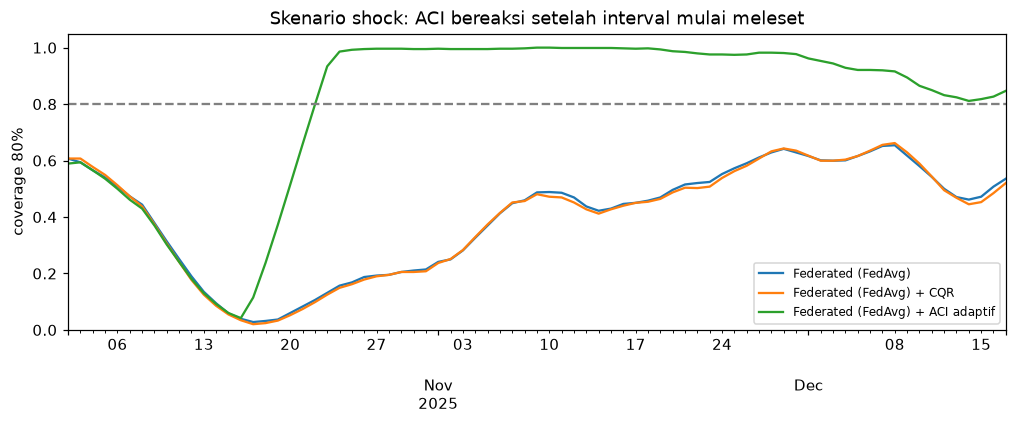

In [4]:
def rolling_cov(r, m, w=7):
    inside = []
    for c, p in zip(r.clients, r.preds[m]):
        inside.append(((c.test.y >= p[..., 1]) & (c.test.y <= p[..., 5])).mean(axis=1))
    return pd.Series(np.mean(inside, axis=0), index=r.sim.dates[r.clients[0].test.origins]).rolling(w, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 3.5))
for m in ["fedavg", "fedavg+cqr", "fedavg+aci"]:
    rolling_cov(results["shock"], m).plot(ax=ax, label=method_label(m))
ax.axhline(0.8, color="grey", ls="--"); ax.set_ylim(0, 1.05); ax.set_ylabel("coverage 80%")
ax.set_title("Skenario shock: ACI bereaksi setelah interval mulai meleset"); ax.legend(fontsize=8)

## Sensitivitas ACI terhadap gamma & window
`gamma` = seberapa cepat alpha bereaksi; `window` = berapa banyak skor terbaru yang dipakai.

In [5]:
rows = []
for s in ["normal", "shock"]:
    r = results[s]
    for g in [0.005, 0.01, 0.02, 0.05]:
        for w in [30, 60]:
            ev = [evaluate(c.test.y, aci(c.val.y, pv, c.val.origins, c.test.y, pt, c.test.origins, gamma=g, window=w))
                  for c, pv, pt in zip(r.clients, r.preds_val["fedavg"], r.preds["fedavg"])]
            rows.append({"skenario": s, "gamma": g, "window": w, **pd.DataFrame(ev).mean()[["CRPS", "Coverage80", "Lebar80"]]})
pd.DataFrame(rows).pivot_table(index=["gamma", "window"], columns="skenario", values=["CRPS", "Coverage80"])

CRPS        Coverage80       
skenario     normal  shock     normal  shock
gamma window                                
0.005 30      0.204  0.517      0.806  0.807
      60      0.202  0.523      0.761  0.785
0.010 30      0.205  0.528      0.811  0.809
      60      0.203  0.541      0.773  0.804
0.020 30      0.207  0.551      0.817  0.816
      60      0.206  0.575      0.790  0.822
0.050 30      0.212  0.588      0.823  0.817
      60      0.213  0.621      0.810  0.834

## Hasil negatif: koreksi bias online
Ide: selain melebarkan interval, geser juga *pusat* prediksi sebesar median residual terbaru.
Hasilnya ternyata **lebih buruk** di semua skenario. Shock berbentuk "V", sehingga residual lama justru
mendorong prediksi ke arah yang salah saat data sudah pulih. Pada kondisi normal, model sendiri sudah
memakai data terbaru, jadi koreksi tambahan hanya menambah noise. Hasil negatif ini tetap dicatat.

In [6]:
rows = []
for s in ["normal", "shock"]:
    r = results[s]
    for bw in [None, 14, 28]:
        ev = [evaluate(c.test.y, aci(c.val.y, pv, c.val.origins, c.test.y, pt, c.test.origins, bias_window=bw))
              for c, pv, pt in zip(r.clients, r.preds_val["fedavg"], r.preds["fedavg"])]
        rows.append({"skenario": s, "koreksi bias": bw or "tanpa", **pd.DataFrame(ev).mean()[["MAE", "CRPS", "Coverage80"]]})
pd.DataFrame(rows).set_index(["skenario", "koreksi bias"])

MAE   CRPS  Coverage80
skenario koreksi bias                          
normal   tanpa         0.353  0.205       0.811
         14            0.413  0.249       0.799
         28            0.365  0.226       0.812
shock    tanpa         0.654  0.528       0.809
         14            0.764  0.536       0.827
         28            0.706  0.519       0.834

## Kesimpulan
- Conformal prediction adalah lapisan "kejujuran" yang murah, bisa dipasang di atas model apa pun, dan
  **tetap menjaga privasi** karena kalibrasinya lokal.
- **ACI** adalah satu-satunya metode di prototipe ini yang tetap terkalibrasi saat shock.
- Batasannya: conformal hanya memperbaiki **lebar** interval, bukan **akurasi** pusatnya. Untuk forecast yang
  akurat saat rezim berubah, dibutuhkan model yang bisa beradaptasi atau membangkitkan skenario (notebook 08).